Iteration 1000 : Loss 3443.1940
Iteration 2000 : Loss 3093.9941
Iteration 3000 : Loss 2978.9778
Iteration 4000 : Loss 2933.7118
Iteration 5000 : Loss 2914.6826

[프로젝트 1 최종 결과] Test MSE: 2866.9042


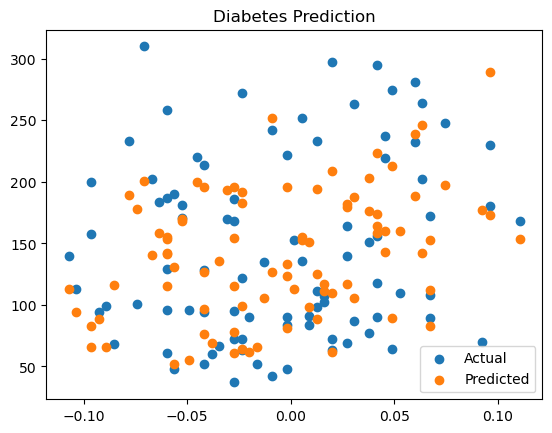

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split

# 1. 데이터 가져오기 및 준비
data = load_diabetes()
df_X = data.data
df_y = data.target

X = np.array(df_X)
y = np.array(df_y)

# 2. train / test 데이터 분리
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. 모델 및 손실함수, 기울기 함수 준비
def model(X, W, b):
    return X.dot(W) + b

def MSE(a, b):
    return ((a - b) ** 2).mean()

def loss(X, W, b, y):
    predictions = model(X, W, b)
    return MSE(predictions, y)

def gradient(X, W, b, y):
    N = len(y)
    y_pred = model(X, W, b)
    dW = 1/N * 2 * X.T.dot(y_pred - y)
    db = 2 * (y_pred - y).mean()
    return dW, db

# 4. 하이퍼 파라미터 설정 및 학습
W = np.random.rand(X_train.shape[1])
b = np.random.rand()
LEARNING_RATE = 0.1 

losses = []
for i in range(1, 5001):
    dW, db = gradient(X_train, W, b, y_train)
    W -= LEARNING_RATE * dW
    b -= LEARNING_RATE * db
    L = loss(X_train, W, b, y_train)
    losses.append(L)
    if i % 1000 == 0:
        print(f'Iteration {i} : Loss {L:.4f}')

# 5. 성능 확인 및 시각화
prediction = model(X_test, W, b)
mse = loss(X_test, W, b, y_test)
print(f"\n[프로젝트 1 최종 결과] Test MSE: {mse:.4f}")

plt.scatter(X_test[:, 0], y_test, label='Actual')
plt.scatter(X_test[:, 0], prediction, label='Predicted')
plt.legend()
plt.title("Diabetes Prediction")
plt.show()

[프로젝트 2 최종 결과] Test MSE: 19953.7649
[프로젝트 2 최종 결과] Test RMSE: 141.2578


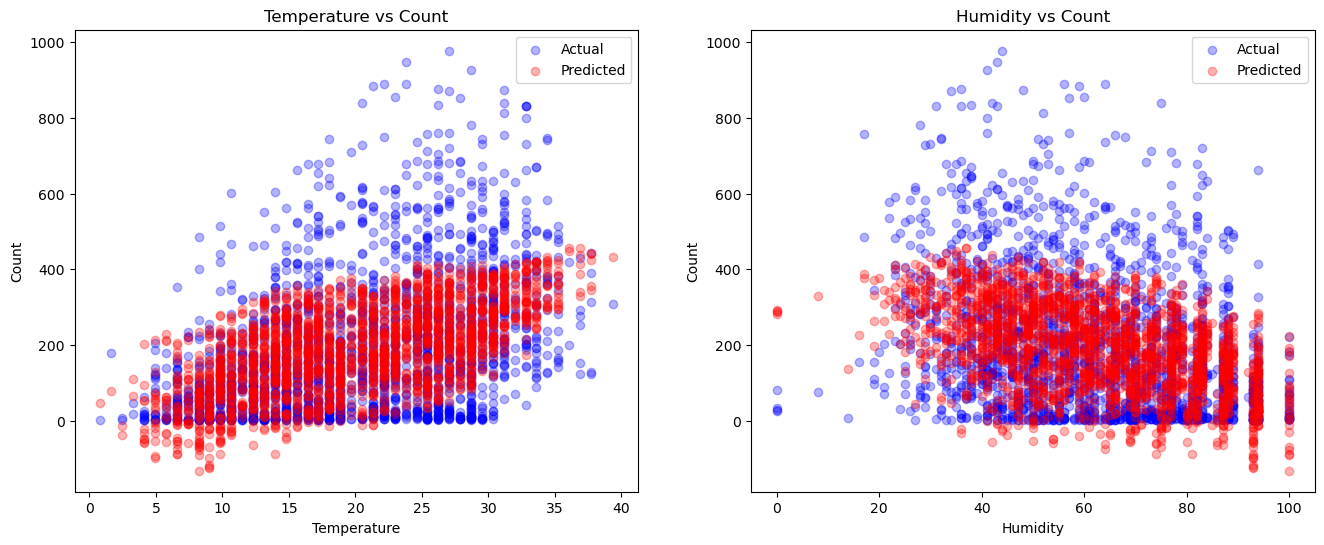

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

# 1. 데이터 가져오기
train = pd.read_csv("~/data/data/bike-sharing-demand/train.csv")

# 2. datetime 컬럼 변환 및 연/월/일/시/분/초 컬럼 생성
train['datetime'] = pd.to_datetime(train['datetime'])
train['year'] = train['datetime'].dt.year
train['month'] = train['datetime'].dt.month
train['day'] = train['datetime'].dt.day
train['hour'] = train['datetime'].dt.hour
train['minute'] = train['datetime'].dt.minute
train['second'] = train['datetime'].dt.second

# 3. X, y 컬럼 선택 및 분리 (성능 향상을 위해 feature 최적화)
features = ['year', 'month', 'hour', 'temp', 'atemp', 'humidity', 'windspeed', 'season', 'weather', 'workingday']
X = train[features]
y = train['count']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 4. 모델 학습
model = LinearRegression()
model.fit(X_train, y_train)

# 5. 예측 및 손실함수 계산
y_pred = model.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)

print(f"[프로젝트 2 최종 결과] Test MSE: {mse:.4f}")
print(f"[프로젝트 2 최종 결과] Test RMSE: {rmse:.4f}")

# 6. 예측 결과 시각화 (temp와 humidity 기준)
fig, axs = plt.subplots(1, 2, figsize=(16, 6))

# temp vs count 시각화
axs[0].scatter(X_test['temp'], y_test, color='blue', label='Actual', alpha=0.3)
axs[0].scatter(X_test['temp'], y_pred, color='red', label='Predicted', alpha=0.3)
axs[0].set_xlabel('Temperature')
axs[0].set_ylabel('Count')
axs[0].set_title('Temperature vs Count')
axs[0].legend()

# humidity vs count 시각화
axs[1].scatter(X_test['humidity'], y_test, color='blue', label='Actual', alpha=0.3)
axs[1].scatter(X_test['humidity'], y_pred, color='red', label='Predicted', alpha=0.3)
axs[1].set_xlabel('Humidity')
axs[1].set_ylabel('Count')
axs[1].set_title('Humidity vs Count')
axs[1].legend()

plt.show()